<a href="https://colab.research.google.com/github/LarsVoermans/master-thesis-pead/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CSV
merged = pd.read_csv("Offical_Dataset.csv")


print(merged.head())
print(merged.info())

  Ticker EarningsDate  Close_Before  Open_After    Return  EPS_Estimate  \
0      A   2015-02-17     36.745716   37.633462  0.887746          0.41   
1      A   2015-05-18     38.570229   38.139015 -0.431214          0.39   
2      A   2015-08-17     35.548782   35.971882  0.423099          0.41   
3      A   2015-11-16     33.917793   33.668737 -0.249056          0.47   
4      A   2016-02-16     33.501831   32.576867 -0.924964          0.43   

   EPS_Actual  Surprise_Pct  Year  Month  ...  Sales/Stockholders Equity  \
0        0.41          0.19  2015      2  ...                   1.317667   
1        0.38         -1.62  2015      5  ...                   0.781998   
2        0.44          8.21  2015      8  ...                   0.836213   
3        0.50          5.89  2015     11  ...                   0.909418   
4        0.46          6.44  2016      2  ...                   0.969042   

   Sales/Working Capital Research and Development/Sales  \
0               1.838073         

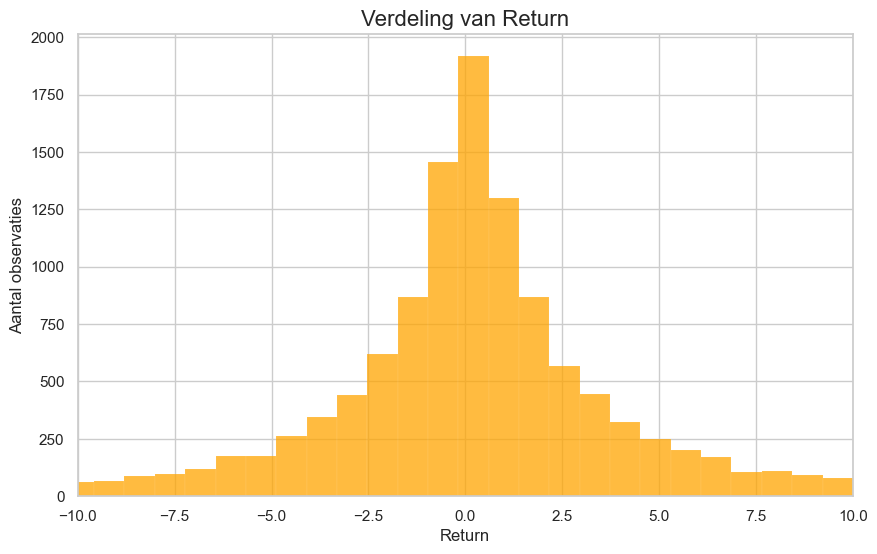

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Histogram
plt.figure(figsize=(10,6))
sns.histplot(merged['Return'], bins=1000, color='orange')  # KDE = curve
plt.title('Verdeling van Return', fontsize=16)
plt.xlabel('Return')
plt.ylabel('Aantal observaties')
plt.xlim(-10, 10)  # optioneel: focus op meeste data
plt.show()

In [ ]:
numerics = merged.select_dtypes(include=['float64', 'int64'])
numerics.describe()

categoricals = merged.select_dtypes(include=['object'])
for col in categoricals.columns:
    print(merged[col].value_counts().head(10))

Ticker
BAX     42
LEN     41
MU      41
MTD     40
NOC     40
NKE     40
NFLX    40
NEM     40
NEE     40
NDAQ    40
Name: count, dtype: int64
EarningsDate
2018-07-26    48
2023-04-27    47
2017-10-26    45
2023-07-27    44
2020-10-29    43
2017-04-27    41
2016-07-28    41
2018-04-26    41
2022-04-28    41
2017-07-27    40
Name: count, dtype: int64
Fiscal year end
2021-12-31    979
2022-12-31    973
2020-12-31    962
2018-12-31    938
2017-12-31    935
2019-12-31    933
2016-12-31    916
2015-12-31    909
2014-12-31    893
2023-12-31    870
Name: count, dtype: int64
Fiscal quarter end
2020-12-31    354
2021-12-31    344
2023-12-31    339
2022-12-31    333
2015-12-31    323
2014-12-31    321
2018-12-31    313
2016-12-31    310
2019-12-31    310
2017-12-31    309
Name: count, dtype: int64
Date
2024-10-31    214
2019-10-31    209
2015-07-31    202
2019-07-31    201
2020-10-31    201
2020-07-31    200
2015-10-31    197
2018-10-31    196
2015-04-30    195
2024-07-31    192
Name: count, dty

In [ ]:
# Extreme Returns: >10 or <-10
extreme_pos = merged[merged['Return'] > 5]
extreme_neg = merged[merged['Return'] < -5]

print("Aantal extreme positieve Returns (>5):", len(extreme_pos))
print("Aantal extreme negatieve Returns (<-5):", len(extreme_neg))

total = len(merged)
print("Percentage extreme positieve:", len(extreme_pos)/total*100)
print("Percentage extreme negatieve:", len(extreme_neg)/total*100)

Aantal extreme positieve Returns (>5): 1554
Aantal extreme negatieve Returns (<-5): 1412
Percentage extreme positieve: 12.363752088471637
Percentage extreme negatieve: 11.23398838411966


                                        Missing_Count  Missing_Percentage
Sales/Working Capital                            4272           33.988384
Trailing P/E to Growth (PEG) ratio               3514           27.957674
Cash Conversion Cycle (Days)                     2632           20.940409
Dividend Yield                                   2610           20.765375
Inventory Turnover                               2299           18.291033
Inventory/Current Assets                         1694           13.477604
Receivables/Current Assets                       1569           12.483093
Pre-tax return on Net Operating Assets           1568           12.475137
Current Liabilities/Total Liabilities            1568           12.475137
Pre-tax Return on Total Earning Assets           1568           12.475137


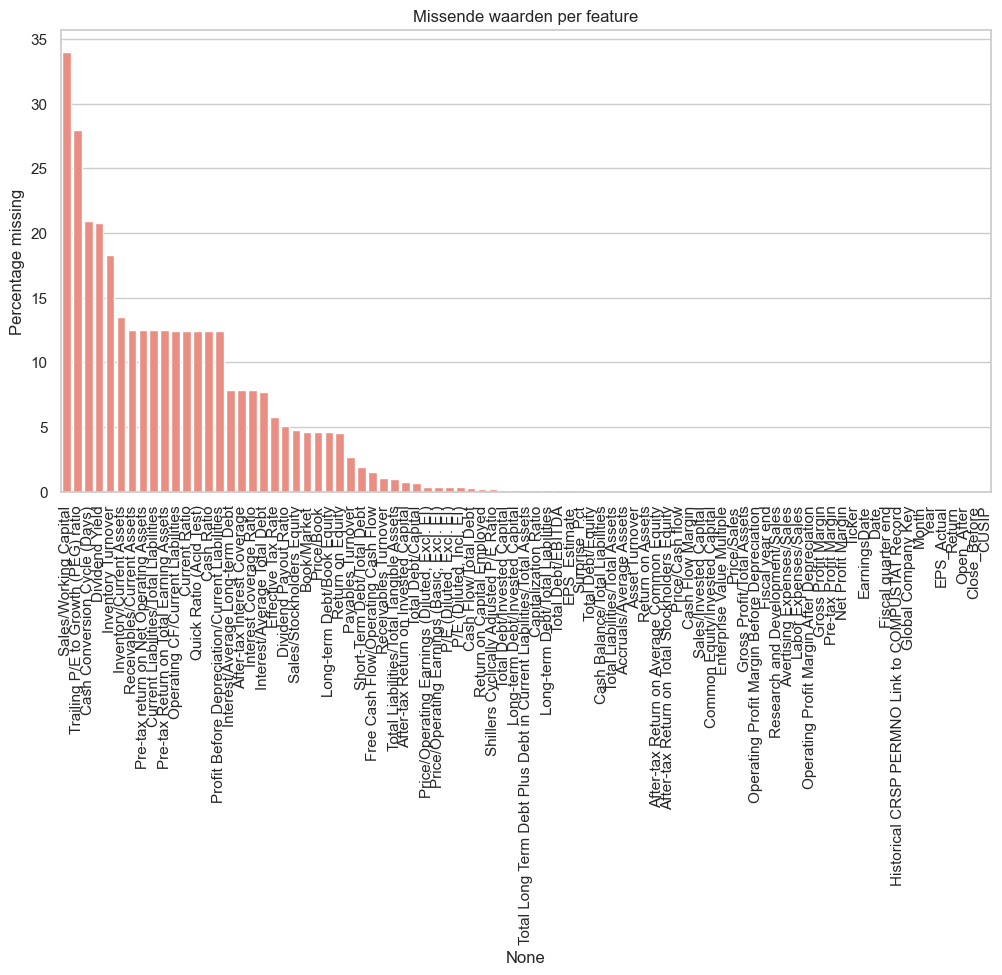

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing values
missing_summary = pd.DataFrame({
    'Missing_Count': merged.isna().sum(),
    'Missing_Percentage': merged.isna().mean()*100
}).sort_values('Missing_Percentage', ascending=False)

print(missing_summary.head(10))  # top 10 features

plt.figure(figsize=(12,6))
sns.barplot(x=missing_summary.index, y=missing_summary['Missing_Percentage'], color='salmon')
plt.xticks(rotation=90)
plt.ylabel('Percentage missing')
plt.title('Missende waarden per feature')
plt.show()

In [ ]:
#Duplicates

duplicate_count = merged.duplicated(subset=['Ticker', 'EarningsDate']).sum()
print(f"Aantal duplicaten op Ticker + EarningsDate: {duplicate_count}")

if duplicate_count == 0:
    print("✅ No duplicate observations found at the company–earnings-date level.")
else:
    print("⚠️ Duplicates found! Inspect or remove them before analysis.")

print("\nDatatype overzicht van de kolommen:")
print(merged.dtypes)

Aantal duplicaten op Ticker + EarningsDate: 6
⚠️ Duplicates found! Inspect or remove them before analysis.

Datatype overzicht van de kolommen:
Ticker                                 object
EarningsDate                           object
Close_Before                          float64
Open_After                            float64
Return                                float64
                                       ...   
Accruals/Average Assets               float64
Price/Book                            float64
Trailing P/E to Growth (PEG) ratio    float64
Dividend Yield                        float64
CUSIP                                  object
Length: 85, dtype: object


In [ ]:
#Sales/working capital missing values
import pandas as pd

merged["SWC_missing"] = merged["Sales/Working Capital"].isna()

merged["Negative_WC"] = merged["Current Ratio"] < 1

pd.crosstab(
    merged["Negative_WC"],
    merged["SWC_missing"],
    normalize="index"
)

SWC_missing,False,True
Negative_WC,,
False,0.839786,0.160214
True,0.042373,0.957627


In [ ]:
#Trailing P/E missing values
merged['PE_Negative'] = merged['P/E (Diluted, Excl. EI)'] <= 0
merged['PEG_Missing'] = merged['Trailing P/E to Growth (PEG) ratio'].isna()

peg_pe_table = pd.crosstab(merged['PEG_Missing'], merged['PE_Negative'], normalize='index') * 100

print("Percentage PEG missing vs negative P/E:")
print(peg_pe_table)

Percentage PEG missing vs negative P/E:
PE_Negative      False      True 
PEG_Missing                      
False        97.393705   2.606295
True         84.006830  15.993170


In [ ]:
merged['Dividend_Payer'] = merged['Dividend Yield'].notna().astype(int)

dividend_relation = pd.crosstab(
    merged['Dividend_Payer'],
    merged['EPS_Actual'] <= 0,
    normalize='index'
) * 100

print(dividend_relation)

EPS_Actual          False     True 
Dividend_Payer                     
0               92.681992  7.318008
1               98.433578  1.566422


Percentiles for positive P/E values:
0.25    14.956026
0.50    22.188170
0.75    32.396634
0.90    51.176573
Name: P/E (Diluted, Excl. EI), dtype: float64


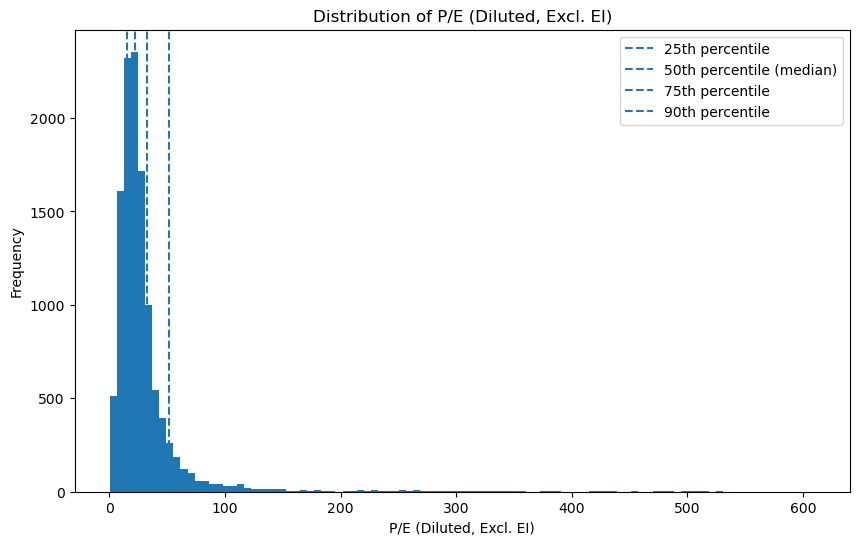

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature = 'P/E (Diluted, Excl. EI)'

pe = merged[feature].dropna()

pe_positive = pe[pe > 0]
percentiles = pe_positive.quantile([0.25, 0.5, 0.75, 0.9])

print("Percentiles for positive P/E values:")
print(percentiles)

plt.figure(figsize=(10, 6))
plt.hist(pe_positive, bins=100)
plt.axvline(percentiles[0.25], linestyle='--', label='25th percentile')
plt.axvline(percentiles[0.50], linestyle='--', label='50th percentile (median)')
plt.axvline(percentiles[0.75], linestyle='--', label='75th percentile')
plt.axvline(percentiles[0.90], linestyle='--', label='90th percentile')

plt.xlabel('P/E (Diluted, Excl. EI)')
plt.ylabel('Frequency')
plt.title('Distribution of P/E (Diluted, Excl. EI)')
plt.legend()
plt.show()

In [ ]:


price_based_features = [
    'Shillers Cyclically Adjusted P/E Ratio',
    'Enterprise Value Multiple',
    'Price/Operating Earnings (Basic, Excl. EI)',
    'Price/Operating Earnings (Diluted, Excl. EI)',
    'P/E (Diluted, Excl. EI)',
    'P/E (Diluted, Incl. EI)',
    'Price/Sales',
    'Price/Cash flow',
    'Price/Book',
    'Trailing P/E to Growth (PEG) ratio',
    'Dividend Yield'
]

for feature in price_based_features:
    print(f"\n{'='*60}")
    print(f"Feature: {feature}")

    values = merged[feature].dropna()

    values_pos = values[values > 0]

    if len(values_pos) < 100:
        print("⚠️ Too few positive observations, skipping visualization.")
        continue

    percentiles = values_pos.quantile([0.25, 0.5, 0.75, 0.9])
    print("Percentiles (positive values only):")
    print(percentiles)

    plt.figure(figsize=(10, 6))
    plt.hist(values_pos, bins=100)

    for q, val in percentiles.items():
        plt.axvline(val, linestyle='--', label=f'{int(q*100)}th percentile')

    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {feature}')
    plt.legend()
    plt.show()



Feature: Shillers Cyclically Adjusted P/E Ratio


NameError: name 'merged' is not defined

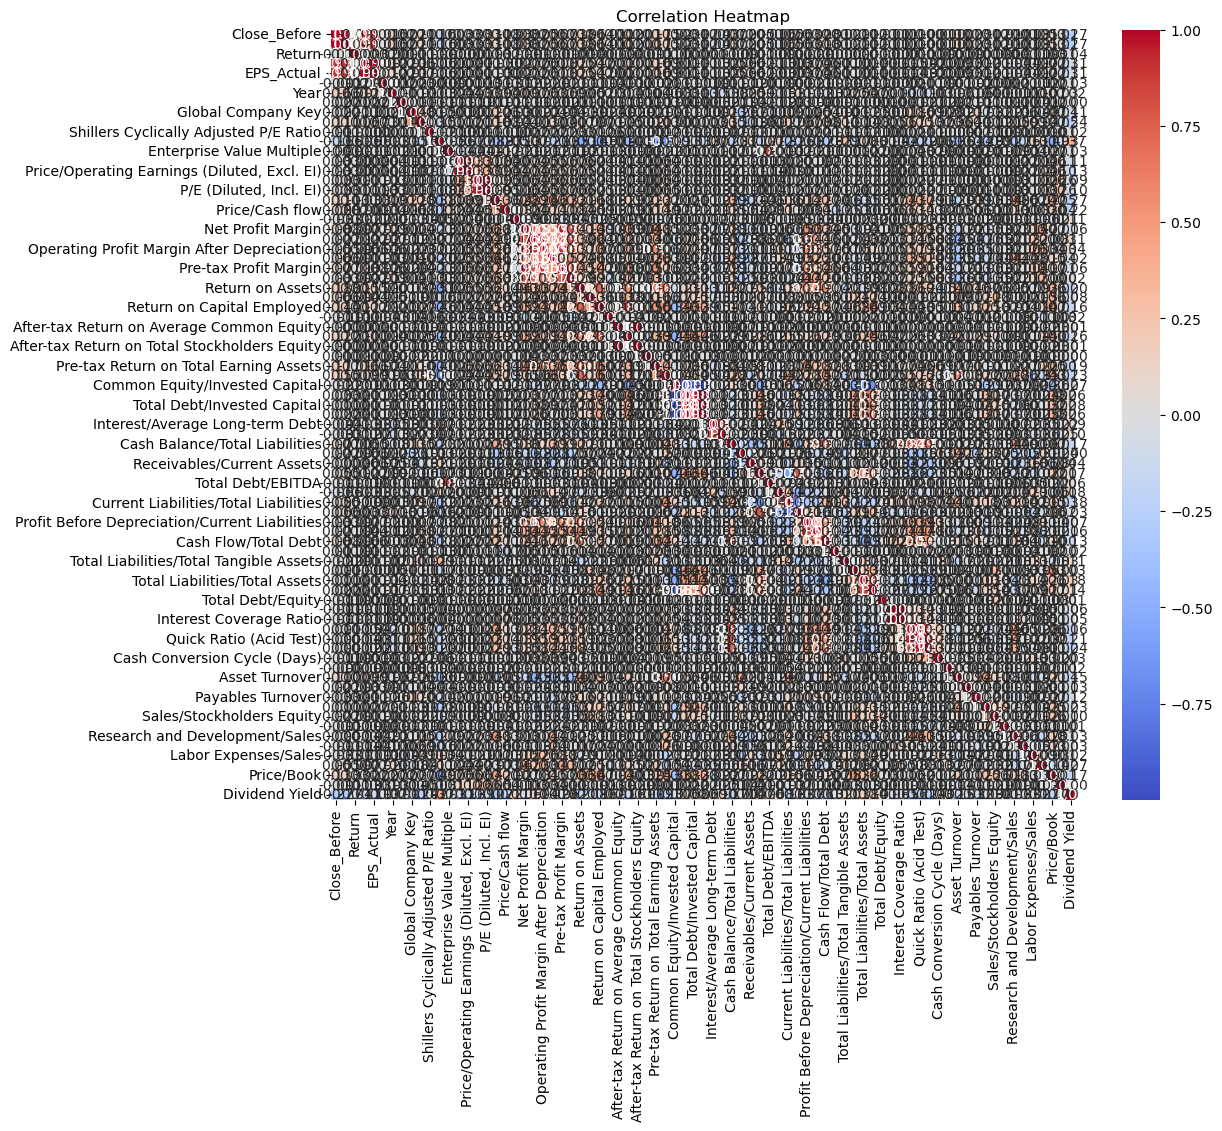

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = merged.select_dtypes(include=['float64', 'int64'])

# Bereken Pearson correlation
corr_matrix = numeric_features.corr(method='pearson')



# Heatmap plotten
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

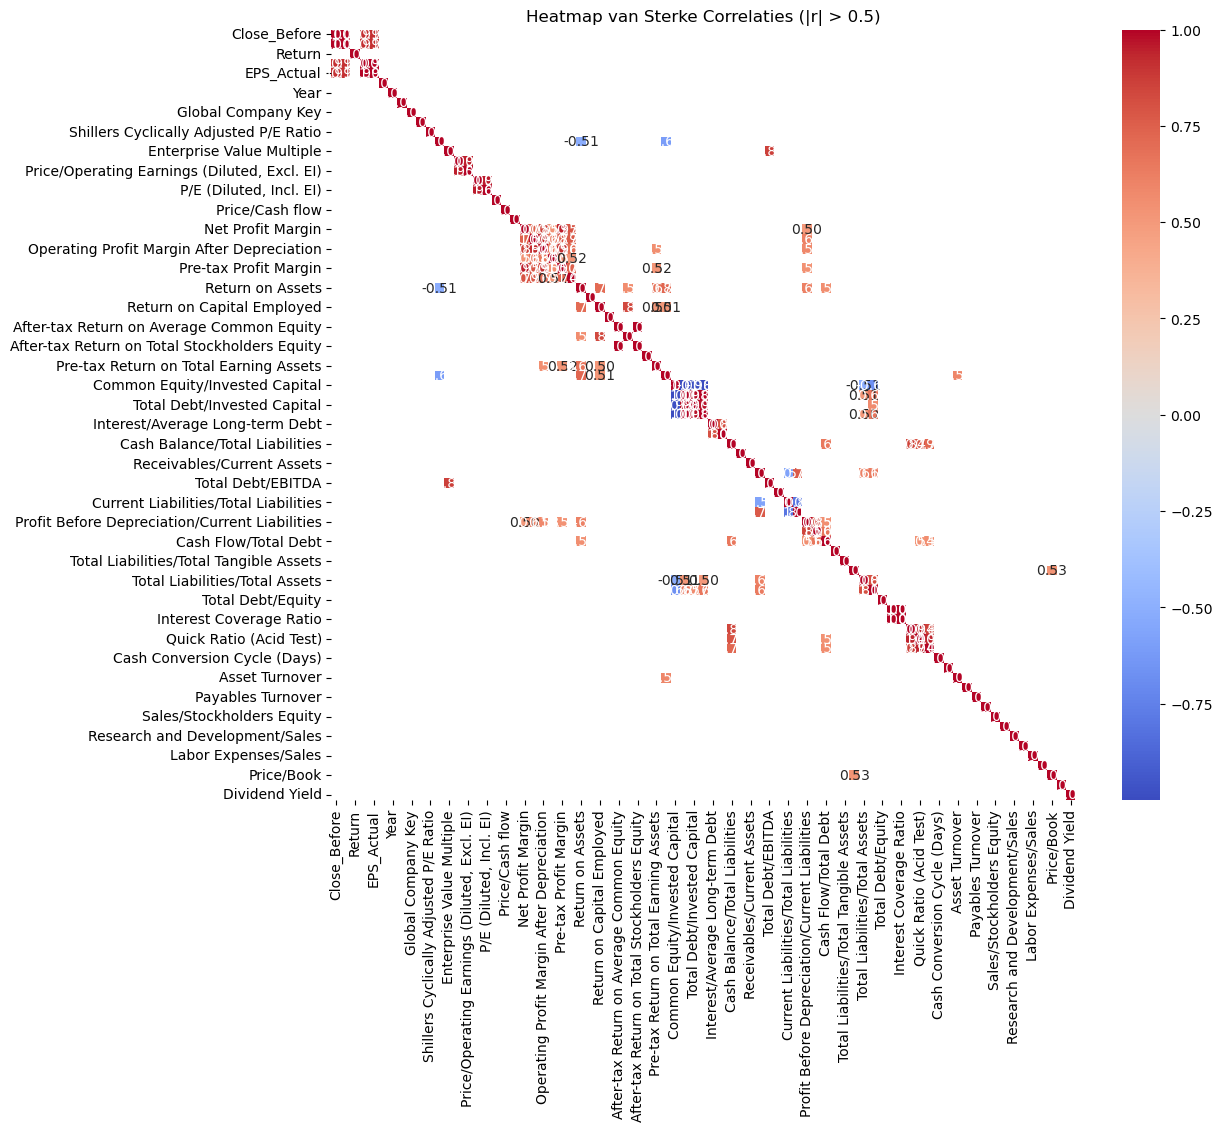

In [ ]:
abs_corr = corr_matrix.abs()

mask = abs_corr < 0.5
filtered_corr = corr_matrix.mask(mask)

plt.figure(figsize=(12,10))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap van Sterke Correlaties (|r| > 0.5)")
plt.show()

In [ ]:
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
top_corr = corr_pairs.sort_values(ascending=False).drop_duplicates()
top_corr.head(50)

After-tax Return on Total Stockholders Equity                       After-tax Return on Average Common Equity         1.000000
Common Equity/Invested Capital                                      Capitalization Ratio                              0.999235
Capitalization Ratio                                                Long-term Debt/Invested Capital                   0.998990
Close_Before                                                        Open_After                                        0.998877
Long-term Debt/Invested Capital                                     Common Equity/Invested Capital                    0.998342
After-tax Interest Coverage                                         Interest Coverage Ratio                           0.995949
EPS_Estimate                                                        EPS_Actual                                        0.992605
Long-term Debt/Invested Capital                                     Total Debt/Invested Capital                